# Import Library

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_ai4i_data

sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

In [2]:
output_dir = '../reports/figures'
os.makedirs(output_dir, exist_ok=True) 

# Load Dataset

In [3]:
df = load_ai4i_data()
display(df.head())

,udi,product_id,type,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,twf,hdf,pwf,osf,rnf
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


# Missing Values

In [4]:
print(df.isnull().sum())

udi                      0
product_id               0
type                     0
air_temperature_k        0
process_temperature_k    0
rotational_speed_rpm     0
torque_nm                0
tool_wear_min            0
machine_failure          0
twf                      0
hdf                      0
pwf                      0
osf                      0
rnf                      0
dtype: int64


No missing values were found in any feature, indicating that no missing value handling was required.

# Data Types

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   udi                    10000 non-null  int64  
 1   product_id             10000 non-null  object 
 2   type                   10000 non-null  object 
 3   air_temperature_k      10000 non-null  float64
 4   process_temperature_k  10000 non-null  float64
 5   rotational_speed_rpm   10000 non-null  int64  
 6   torque_nm              10000 non-null  float64
 7   tool_wear_min          10000 non-null  int64  
 8   machine_failure        10000 non-null  int64  
 9   twf                    10000 non-null  int64  
 10  hdf                    10000 non-null  int64  
 11  pwf                    10000 non-null  int64  
 12  osf                    10000 non-null  int64  
 13  rnf                    10000 non-null  int64  
dtypes: float64(3), int64(9), object(2)
memory usage: 1.1+ M

Apart from *product_id* and *type*, all features were numerical (int64 or float64). Since *product_id* serves only as a unique identifier and does not provide predictive information, no encoding was applied to this feature. Therefore, categorical encoding will be performed only on the *type* feature.

# Statistical Summary

In [6]:
statistik_deskriptif = df.describe().T
display(statistik_deskriptif)

,count,mean,std,min,25%,50%,75%,max
udi,10000.0,5000.50000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
air_temperature_k,10000.0,300.00493,2.000259,295.3,298.30,300.1,301.50,304.5
process_temperature_k,10000.0,310.00556,1.483734,305.7,308.80,310.1,311.10,313.8
rotational_speed_rpm,10000.0,1538.77610,179.284096,1168.0,1423.00,1503.0,1612.00,2886.0
torque_nm,10000.0,39.98691,9.968934,3.8,33.20,40.1,46.80,76.6
tool_wear_min,10000.0,107.95100,63.654147,0.0,53.00,108.0,162.00,253.0
machine_failure,10000.0,0.03390,0.180981,0.0,0.00,0.0,0.00,1.0
twf,10000.0,0.00460,0.067671,0.0,0.00,0.0,0.00,1.0
hdf,10000.0,0.01150,0.106625,0.0,0.00,0.0,0.00,1.0
pwf,10000.0,0.00950,0.097009,0.0,0.00,0.0,0.00,1.0


- **Air and Process Temperature Distribution:** The *air temperature* feature has a mean of 300.00 K with a standard deviation of 2.00 K, while the *process temperature* has a mean of 310.01 K with a standard deviation of 1.48 K. The approximately 10 K difference between the two variables is consistent with the dataset description, indicating that the *process temperature* is maintained at a higher level than the surrounding *air temperature*.

* **Torque Distribution:** The *torque* feature has a mean of 39.99 Nm and a standard deviation of 9.97 Nm, which closely matches the dataset specification of a *torque* centered around 40 Nm. This suggests that the generated *torque* values follow the expected distribution.

+ **Potential Outliers in Rotational Speed:** The *rotational speed* feature ranges from 1,168 rpm to 2,886 rpm. Although the third quartile is 1,612 rpm, the maximum value is considerably higher, indicating the presence of potential high-value outliers that should be further examined using boxplots or other visualization techniques.

+ **Tool Wear Characteristics:** The *tool wear* feature ranges from 0 to 253 minutes, with a median of 108 minutes. Since the maximum value exceeds the typical replacement interval described in the dataset documentation, some observations represent tools operating beyond the recommended wear threshold before failure occurs.

* **Class Imbalance in Machine Failure:** The *machine failure* target has a mean of 0.0339, indicating that only 3.39% of the observations correspond to *machine failures*. This reveals **a significant class imbalance**, suggesting that appropriate imbalance-handling techniques may be required during model development.

# Skewness and Kurtosis

In [7]:
numeric_cols = [
    'air_temperature_k', 
    'process_temperature_k', 
    'rotational_speed_rpm', 
    'torque_nm', 
    'tool_wear_min'
]

skewness = df[numeric_cols].skew()
kurtosis = df[numeric_cols].kurtosis()

distribution = pd.DataFrame({
    'Skewness': skewness,
    'Kurtosis': kurtosis
})

display(distribution)

,Skewness,Kurtosis
air_temperature_k,0.114274,-0.835962
process_temperature_k,0.015027,-0.499734
rotational_speed_rpm,1.993171,7.392945
torque_nm,-0.009517,-0.013241
tool_wear_min,0.027292,-1.166737


- **Air Temperature Distribution:** The *air_temperature_k* feature has a skewness of **0.114**, indicating an approximately symmetric distribution with a slight positive skew. Its kurtosis of **−0.836** suggests a flatter-than-normal (platykurtic) distribution, implying relatively fewer extreme values.

- **Process Temperature Distribution:** The *process_temperature_k* feature has a skewness of **0.015**, which is very close to zero, indicating a nearly symmetric distribution. Its kurtosis of **−0.500** also suggests a slightly flatter-than-normal distribution with relatively light tails.

- **Rotational Speed Distribution:** The *rotational_speed_rpm* feature exhibits a **strong positive skew** (skewness = **1.993**), indicating a long right tail where a small number of observations have unusually high rotational speeds. Its high kurtosis of **7.393** further suggests the presence of heavy tails and potential extreme outliers, which will be further investigated during the outlier analysis stage.

- **Torque Distribution:** The *torque_nm* feature has a skewness of **−0.010**, which is very close to zero, indicating an approximately symmetric distribution. Its kurtosis of **−0.013** is also close to zero, suggesting that the distribution closely resembles a normal distribution.

- **Tool Wear Distribution:** The *tool_wear_min* feature has a skewness of **0.027**, indicating an approximately symmetric distribution. However, its kurtosis of **−1.167** suggests a flatter-than-normal (platykurtic) distribution, meaning that observations are more evenly spread with relatively fewer extreme values.

# Categorical Analysis

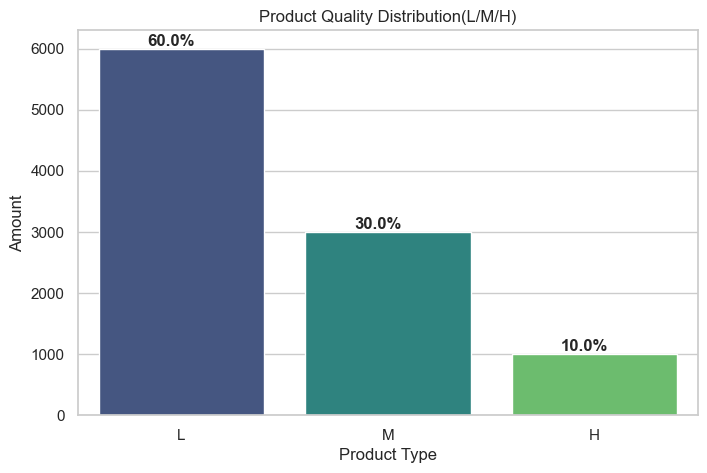

In [8]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='type', order=['L', 'M', 'H'], palette='viridis')

total = len(df)
for p in ax.patches:
    persentase = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_height() + 50
    ax.annotate(persentase, (x, y), ha='center', fontweight='bold')

plt.title('Product Quality Distribution(L/M/H)')
plt.ylabel('Amount')
plt.xlabel('Product Type')

file_path = os.path.join(output_dir, "categorical_product_type.png")
plt.savefig(file_path, dpi=300, bbox_inches='tight')

plt.show()

 The distribution of the *product type* does not fully align with the proportions described in the dataset documentation. While the documentation states that the product quality categories follow a **50% (L), 30% (M), and 20% (H)** distribution, the observed dataset contains **60% (L), 30% (M), and 10% (H)**. This indicates that the dataset includes a higher proportion of low-quality products and a lower proportion of high-quality products than originally documented.

# Boxplot

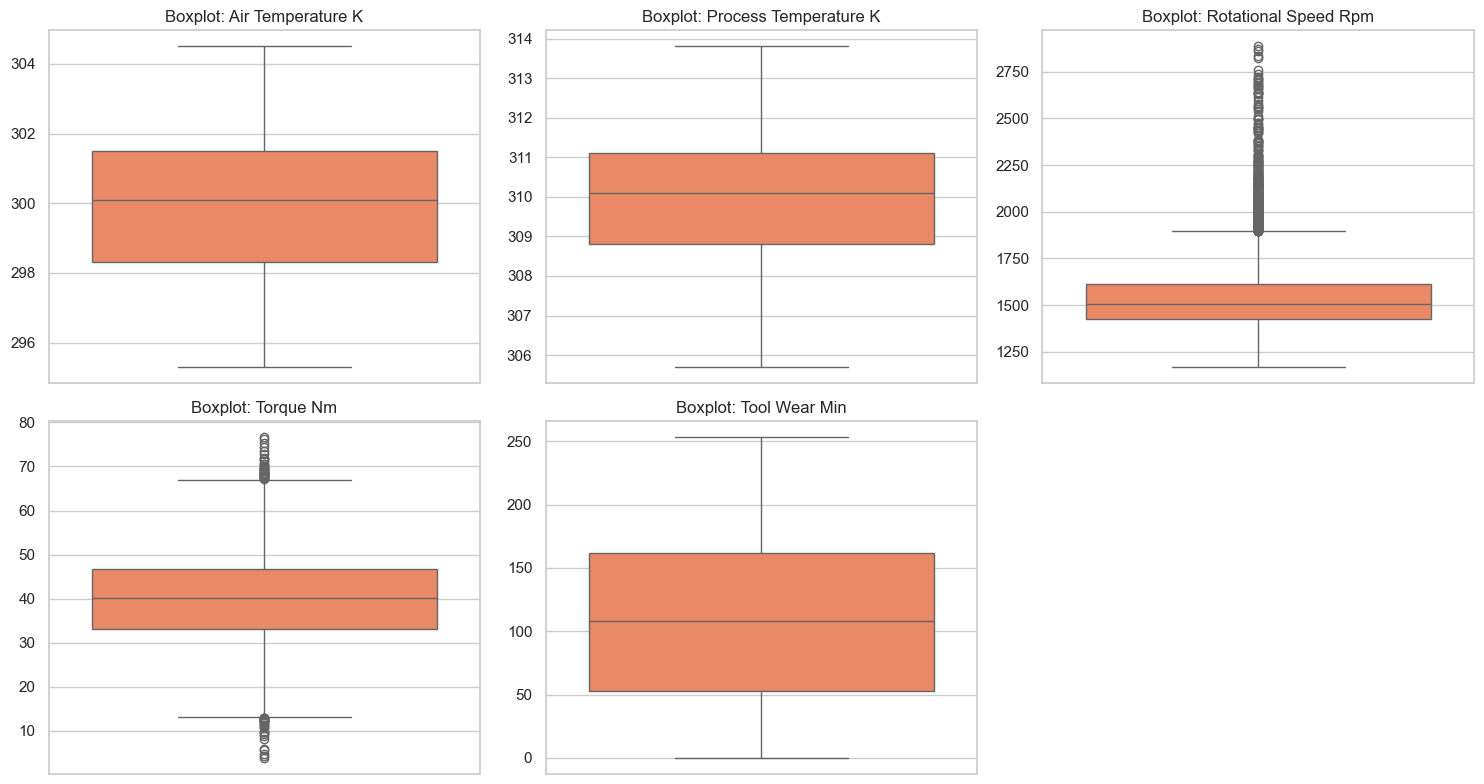

In [9]:
plt.figure(figsize=(15, 8))

for i, cols in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[cols], color='coral')
    plt.title(f'Boxplot: {cols.replace("_", " ").title()}')
    plt.ylabel('')

plt.tight_layout()

file_path = os.path.join(output_dir, "boxplot_all_numeric_features.png")
plt.savefig(file_path, dpi=300, bbox_inches='tight')

plt.show()

- **Air Temperature and Process Temperature:** Both *air_temperature_k* and *process_temperature_k* exhibit approximately symmetric distributions with no apparent outliers. The median is located near the center of each box, while the whiskers extend evenly in both directions, indicating relatively stable variability and consistent operating temperature ranges.

- **Rotational Speed:** The *rotational_speed_rpm* feature contains a considerable number of upper outliers beyond the upper whisker, extending from approximately **1,900 rpm** to nearly **2,900 rpm**. This observation is consistent with the previously identified positive skewness and suggests that a small proportion of samples exhibit unusually high rotational speeds. These observations will be further investigated during the outlier analysis stage.

- **Torque:** The *torque_nm* feature contains outliers on both the lower and upper ends of the distribution, indicating the presence of unusually low and high torque values. Despite these extreme observations, the median remains close to **40 Nm**, suggesting that most samples are centered around the expected operating torque.

- **Tool Wear:** The *tool_wear_min* feature exhibits a relatively wide interquartile range, indicating substantial variability in tool usage. Although the distribution spans from **0** to approximately **253 minutes**, no observations are identified as outliers according to the IQR criterion, suggesting that the observed values fall within the expected variability of the dataset.

# Histogram

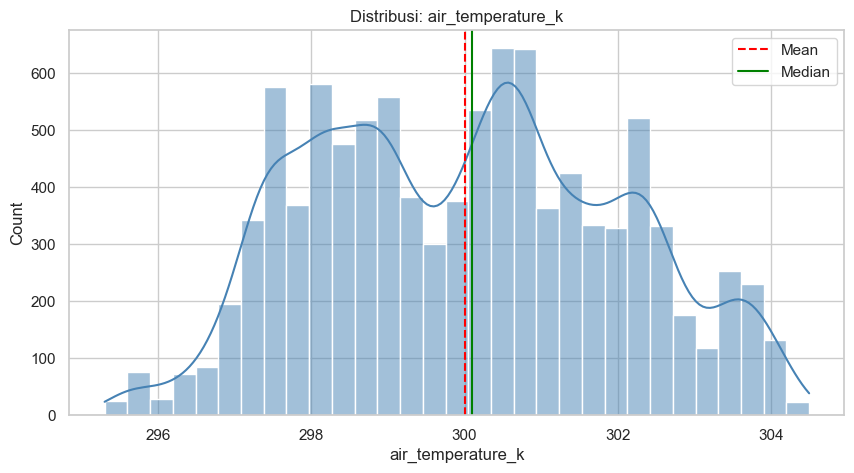

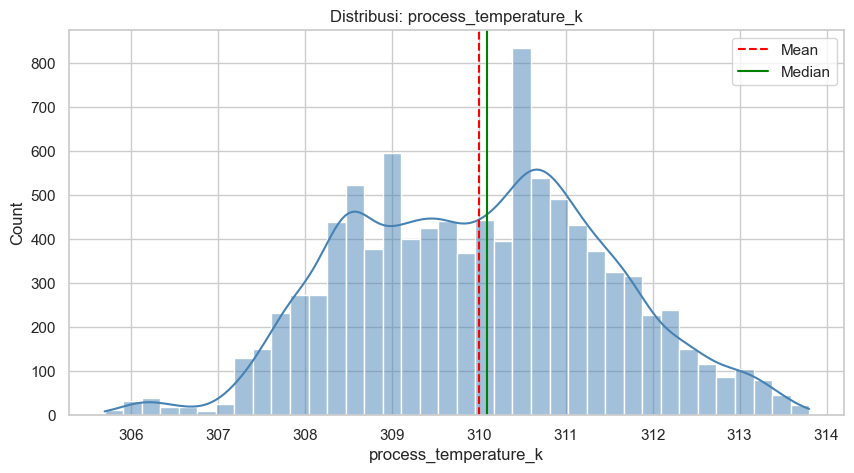

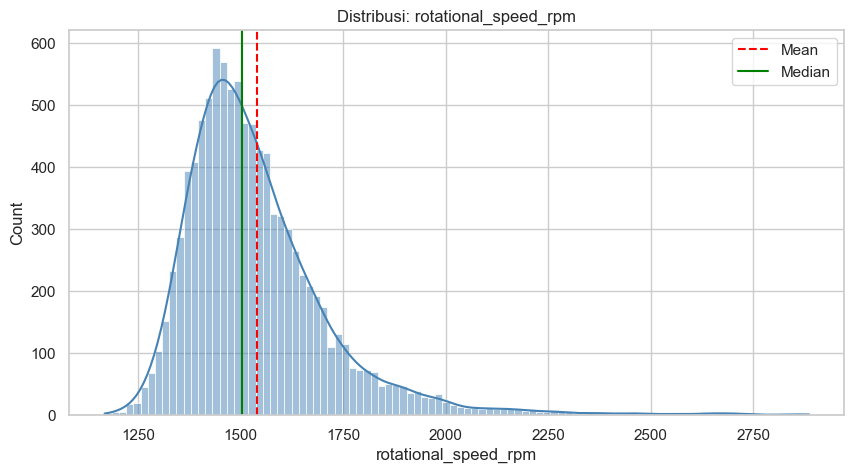

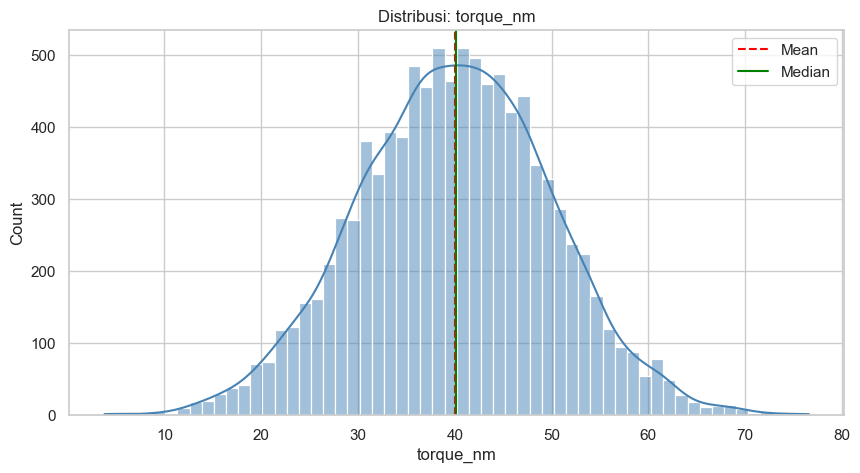

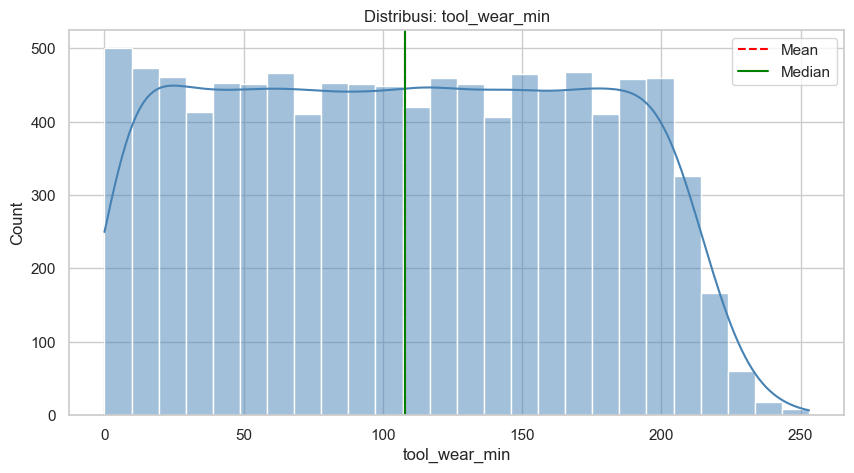

In [10]:
for cols in numeric_cols:
    plt.figure(figsize=(10, 5))
    
    sns.histplot(df[cols], kde=True, color='steelblue')
    plt.axvline(df[cols].mean(), color='red', linestyle='--', label='Mean')
    plt.axvline(df[cols].median(), color='green', linestyle='-', label='Median')
    
    plt.title(f"Distribusi: {cols}")
    plt.legend()
    
    file_path = os.path.join(output_dir, f"hist_{cols}.png")
    
    plt.savefig(file_path, dpi=300, bbox_inches='tight')
    plt.show()

- **Air and Process Temperature:** Both *air_temperature_k* and *process_temperature_k* display approximately symmetric distributions. While they resemble normal distributions, their slightly flat peaks (platykurtic) indicate that the temperatures fluctuate evenly within a specific, well-controlled range without extreme spikes, confirming the stability of the manufacturing environment.

- **Rotational Speed:** The *rotational_speed_rpm* histogram visually confirms a **strong right-skewed distribution**. The massive peak on the left shows that the machine predominantly operates between 1,400 and 1,600 rpm. The long, trailing tail to the right clearly illustrates the occurrence of exceptionally high-speed operations, perfectly mirroring the dense cluster of outliers previously detected in the boxplot.

- **Torque:** The *torque_nm* feature exhibits a nearly perfect bell-shaped curve (normal distribution) centered tightly around its mean and median of approximately 40 Nm. This indicates that the physical load and power required by the machine are highly consistent during standard operations.

- **Tool Wear:** The *tool_wear_min* histogram displays a highly uniform (flat) distribution rather than a bell curve. This aligns with the physical reality of the manufacturing process: tool wear accumulates linearly and steadily over time, and tools are randomly replaced at various intervals, causing the data points to be evenly distributed across the 0 to 250 minutes operational spectrum.